In [1]:
# Phosphocode Results Analysis

#This notebook analyses the machine learning results obtained from 85 usable kinases across 8 regression models using the MCF7 cell line.

#The analysis includes:
#Model performance comparison
#Identification of best and worst-performing kinase- model combinations
#Gene name annotation
#R2 versus phosphosite count analysis
#Predicted versus actual KSEA z-score visualization
#Interpretation of model performance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load the machine learning result files

all_results = pd.read_csv("all_models_85_kinases.csv")

best_results = pd.read_csv("best_model_per_kinase.csv")

In [4]:
# Check the dimensions of both datasets

print("All model results shape:", all_results.shape)
print("Best model results shape:",best_results.shape)

All model results shape: (680, 6)
Best model results shape: (85, 6)


In [5]:
# Display the first five rows of both datasets

print("First five rows of all model results:")
display(all_results.head())

print("First five rows of best model results:")
display(best_results.head())

First five rows of all model results:


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,RandomForest,-0.130046,0.308177,-0.634771,1.184971
1,O00418,XGBoost,-0.543112,0.278270,-1.498010,1.810693
2,O00418,PLS,0.045130,0.427042,-0.401425,1.015829
3,O00418,SVR,0.028713,0.430091,-0.542878,1.118362
4,O00418,Lasso,0.005693,0.265054,-0.126371,0.816455


First five rows of best model results:


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,Lasso,0.005693,0.265054,-0.126371,0.816455
1,O14578,RandomForest,-0.611219,0.755537,0.023617,0.480279
2,O15075,Lasso,0.200674,0.369384,0.122552,0.938032
3,O43318,GradientBoosting,-1.415528,2.148830,0.230035,0.643804
4,O43353,PLS,0.667993,0.148958,0.556355,0.179804


In [6]:
# Get kinase information from the Kinepik API

import requests

url = "https://kinepik.org/api/0/kinases/all"

response = requests.get(url)

kinase_info = pd.DataFrame(response.json())

# Create a clean mapping between UniProt ID and gene name
kinase_gene_mapping = pd.DataFrame({
    "Kinase": kinase_info["UniprotID"],
    "GeneName": kinase_info["GeneInfo"].apply(lambda x: x["MappedGene"])
})

# Display the first five rows
display(kinase_gene_mapping.head())

,Kinase,GeneName
0,P06239,LCK
1,P12931,SRC
2,P06241,FYN
3,P00519,ABL1
4,P24941,CDK2


In [7]:
all_results_with_genes = all_results.merge(
    kinase_gene_mapping,
    on="Kinase",
    how="left"
)

print("All results shape:", all_results_with_genes.shape)

print(
    "Missing gene names:",
    all_results_with_genes["GeneName"].isna().sum()
)

All results shape: (680, 7)
Missing gene names: 0


In [8]:
# Add gene names to best results

best_results_with_genes = best_results.merge(
    kinase_gene_mapping,
    on="Kinase",
    how="left"
)

# Arrange GeneName immediately after Kinase

best_results_with_genes = best_results_with_genes[
    [
        "Kinase",
        "GeneName",
        "Model",
        "CV Mean R²",
        "CV Std R²",
        "Test R²",
        "Test MSE"
    ]
]

# Sort best results from highest to lowest Test R²

best_results_sorted = best_results_with_genes.sort_values(
    by="Test R²",
    ascending=False
).reset_index(drop=True)

display(best_results_sorted)

,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,PLS,0.965607,0.015750,0.974440,0.019708
1,Q96QT4,TRPM7,SVR,0.751555,0.142106,0.875395,0.245826
2,Q96RR4,CAMKK2,SVR,-0.172263,0.997043,0.584682,0.118887
3,Q9H0K1,SIK2,Lasso,0.494756,0.227394,0.565761,0.682778
4,O43353,RIPK2,PLS,0.667993,0.148958,0.556355,0.179804
...,...,...,...,...,...,...,...
80,Q9NYV4,CDK12,Lasso,-0.141184,0.589356,-0.355345,0.387042
81,Q05655,PRKCD,SVR,-0.953638,0.847001,-0.377291,1.539174
82,Q14004,CDK13,PLS,-0.514023,0.592186,-0.423072,0.602091
83,Q8IVT5,KSR1,Lasso,-0.015523,0.257833,-0.473382,6.087999


In [9]:
# Display the top 10 best-performing results

top_10 = best_results_sorted.head(10)

display(top_10)

,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,PLS,0.965607,0.015750,0.974440,0.019708
1,Q96QT4,TRPM7,SVR,0.751555,0.142106,0.875395,0.245826
2,Q96RR4,CAMKK2,SVR,-0.172263,0.997043,0.584682,0.118887
3,Q9H0K1,SIK2,Lasso,0.494756,0.227394,0.565761,0.682778
4,O43353,RIPK2,PLS,0.667993,0.148958,0.556355,0.179804
5,P49759,CLK1,ElasticNet,0.020852,0.384344,0.477334,0.364380
6,O60885,BRD4,RandomForest,-0.846320,0.959622,0.456306,0.172688
7,Q13177,PAK2,MLP,-1.598612,1.834458,0.445141,0.437979
8,O96013,PAK4,PLS,-0.146721,0.253854,0.435931,0.674297
9,Q96GX5,MASTL,PLS,-0.625983,0.634977,0.413474,0.175116


In [10]:
# Identify the best and worst performing kinase-model combinations

best_performer = best_results_sorted.iloc[0]
worst_performer = best_results_sorted.iloc[-1]

print("BEST PERFORMING KINASE-MODEL COMBINATION")
print(best_performer)

print("\nWORST PERFORMING KINASE-MODEL COMBINATION")
print(worst_performer)

BEST PERFORMING KINASE-MODEL COMBINATION
Kinase          Q9UKE5
GeneName          TNIK
Model              PLS
CV Mean R²    0.965607
CV Std R²      0.01575
Test R²        0.97444
Test MSE      0.019708
Name: 0, dtype: object

WORST PERFORMING KINASE-MODEL COMBINATION
Kinase          Q13263
GeneName        TRIM28
Model            Lasso
CV Mean R²   -0.509958
CV Std R²     1.167272
Test R²      -0.613215
Test MSE      0.218328
Name: 84, dtype: object


In [11]:
# Display the top 10 best and worst-performing kinase-model combinations

top_10_best = best_results_sorted.head(10)

top_10_worst = best_results_sorted.tail(10).sort_values(
    by="Test R²",
    ascending=True
).reset_index(drop=True)

print("TOP 10 BEST-PERFORMING KINASE-MODEL COMBINATIONS")
display(top_10_best)

print("TOP 10 WORST-PERFORMING KINASE-MODEL COMBINATIONS")
display(top_10_worst)

TOP 10 BEST-PERFORMING KINASE-MODEL COMBINATIONS


,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q9UKE5,TNIK,PLS,0.965607,0.015750,0.974440,0.019708
1,Q96QT4,TRPM7,SVR,0.751555,0.142106,0.875395,0.245826
2,Q96RR4,CAMKK2,SVR,-0.172263,0.997043,0.584682,0.118887
3,Q9H0K1,SIK2,Lasso,0.494756,0.227394,0.565761,0.682778
4,O43353,RIPK2,PLS,0.667993,0.148958,0.556355,0.179804
5,P49759,CLK1,ElasticNet,0.020852,0.384344,0.477334,0.364380
6,O60885,BRD4,RandomForest,-0.846320,0.959622,0.456306,0.172688
7,Q13177,PAK2,MLP,-1.598612,1.834458,0.445141,0.437979
8,O96013,PAK4,PLS,-0.146721,0.253854,0.435931,0.674297
9,Q96GX5,MASTL,PLS,-0.625983,0.634977,0.413474,0.175116


TOP 10 WORST-PERFORMING KINASE-MODEL COMBINATIONS


,Kinase,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,Q13263,TRIM28,Lasso,-0.509958,1.167272,-0.613215,0.218328
1,Q8IVT5,KSR1,Lasso,-0.015523,0.257833,-0.473382,6.087999
2,Q14004,CDK13,PLS,-0.514023,0.592186,-0.423072,0.602091
3,Q05655,PRKCD,SVR,-0.953638,0.847001,-0.377291,1.539174
4,Q9NYV4,CDK12,Lasso,-0.141184,0.589356,-0.355345,0.387042
5,O75676,RPS6KA4,SVR,-1.638522,1.077330,-0.311944,0.806751
6,Q14680,MELK,SVR,-0.095054,0.452361,-0.212206,0.214819
7,Q00536,CDK16,RandomForest,-0.376973,0.530117,-0.198012,0.597876
8,P06493,CDK1,MLP,-0.817945,0.897187,-0.195731,2.807697
9,Q8IV63,VRK3,Lasso,-0.236276,0.216517,-0.195259,0.797068


In [12]:
#Saving all the important final dataset 

# save all model results with gene names

all_results_with_genes.to_csv(
    "all_results_with_genes.csv",
    index=False 
)

print("Saved: all_results_with_genes.csv")

Saved: all_results_with_genes.csv


In [13]:
#Save best results for eacch kinase

best_results.to_csv(
    "best_results_with_genes.csv",
    index=False 
)

print("Saved: best_results_with_genes.csv")

Saved: best_results_with_genes.csv


In [14]:
#save sorted best results

best_results_sorted.to_csv(
    "best_results_sorted.csv",
    index=False 
)

print("Saved: best_results_sorted.csv")

Saved: best_results_sorted.csv


In [15]:
#Save top 10 best

top_10_best.to_csv(
    "top_10_best_kinases.csv",
    index=False
)

print("Saved: top_10_best_kinases.csv")

Saved: top_10_best_kinases.csv


In [16]:
# save top 10 worst

top_10_worst.to_csv(
    "top_10_worst_kinases.csv",
    index=False 
)

print("Saved: top_10_worst_kinases.csv")

Saved: top_10_worst_kinases.csv


In [17]:
#Load the predictions CSV

predictions = pd.read_csv("all_predictions.csv")

predictions

,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,RandomForest,-1.904592,-1.053086
1,O00418,EEF2K,RandomForest,-1.109755,-1.603663
2,O00418,EEF2K,RandomForest,-1.312516,-1.821441
3,O00418,EEF2K,RandomForest,-0.818783,-1.626157
4,O00418,EEF2K,RandomForest,-1.587355,-1.397229
...,...,...,...,...,...
12915,Q9Y3S1,WNK2,MLP,1.789725,0.224456
12916,Q9Y3S1,WNK2,MLP,-2.529739,0.846868
12917,Q9Y3S1,WNK2,MLP,-0.329718,0.220158
12918,Q9Y3S1,WNK2,MLP,-0.426550,0.797883


In [18]:
#load the best model table
best_models = pd.read_csv("best_results_with_genes.csv")

best_models.head()

,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE
0,O00418,Lasso,0.005693,0.265054,-0.126371,0.816455
1,O14578,RandomForest,-0.611219,0.755537,0.023617,0.480279
2,O15075,Lasso,0.200674,0.369384,0.122552,0.938032
3,O43318,GradientBoosting,-1.415528,2.148830,0.230035,0.643804
4,O43353,PLS,0.667993,0.148958,0.556355,0.179804


In [19]:
# keep only predictions from the best model 

best_predictions = predictions.merge(
    best_models[["Kinase", "Model"]],
    on=["Kinase", "Model"],
    how="inner"
)

best_predictions.head()

,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,Lasso,-1.904592,-0.477737
1,O00418,EEF2K,Lasso,-1.109755,-1.122972
2,O00418,EEF2K,Lasso,-1.312516,-1.481164
3,O00418,EEF2K,Lasso,-0.818783,-1.303635
4,O00418,EEF2K,Lasso,-1.587355,-1.669719


In [20]:
best_predictions.to_csv(
    "best_predictions.csv",
    index=False 
)

print("Saved best_predictions.csv")

Saved best_predictions.csv


In [21]:
print(best_predictions.shape)
best_predictions.head()

(1615, 5)


,Kinase,GeneName,Model,Actual,Predicted
0,O00418,EEF2K,Lasso,-1.904592,-0.477737
1,O00418,EEF2K,Lasso,-1.109755,-1.122972
2,O00418,EEF2K,Lasso,-1.312516,-1.481164
3,O00418,EEF2K,Lasso,-0.818783,-1.303635
4,O00418,EEF2K,Lasso,-1.587355,-1.669719


In [22]:
def plot_actual_vs_predicted(predictions_df, kinase_list, title_prefix):
    """
    Plot Actual vs Predicted scatter plots for multiple kinases.

    Parameters
    ----------
    predictions_df : dataframe
        best_predictions dataframe

    kinase_list : list
        list of kinase IDs

    title_prefix : str
        title shown above plots
    """

    n = len(kinase_list)

    fig, axes = plt.subplots(
        nrows=2,
        ncols=5,
        figsize=(22,9)
    )

    axes = axes.flatten()

    for ax, kinase in zip(axes, kinase_list):

        df = predictions_df[predictions_df["Kinase"] == kinase]

        gene = df["GeneName"].iloc[0]
        model = df["Model"].iloc[0]

        actual = df["Actual"]
        predicted = df["Predicted"]

        ax.scatter(actual, predicted, alpha=0.7)

        # identity line
        mn = min(actual.min(), predicted.min())
        mx = max(actual.max(), predicted.max())

        ax.plot(
            [mn, mx],
            [mn, mx],
            "r--",
            linewidth=1
        )

        ax.set_title(f"{gene} ({model})", fontsize=10)

        ax.set_xlabel("Actual")

        ax.set_ylabel("Predicted")

    plt.suptitle(
        title_prefix,
        fontsize=18
    )

    plt.tight_layout()

    plt.show()



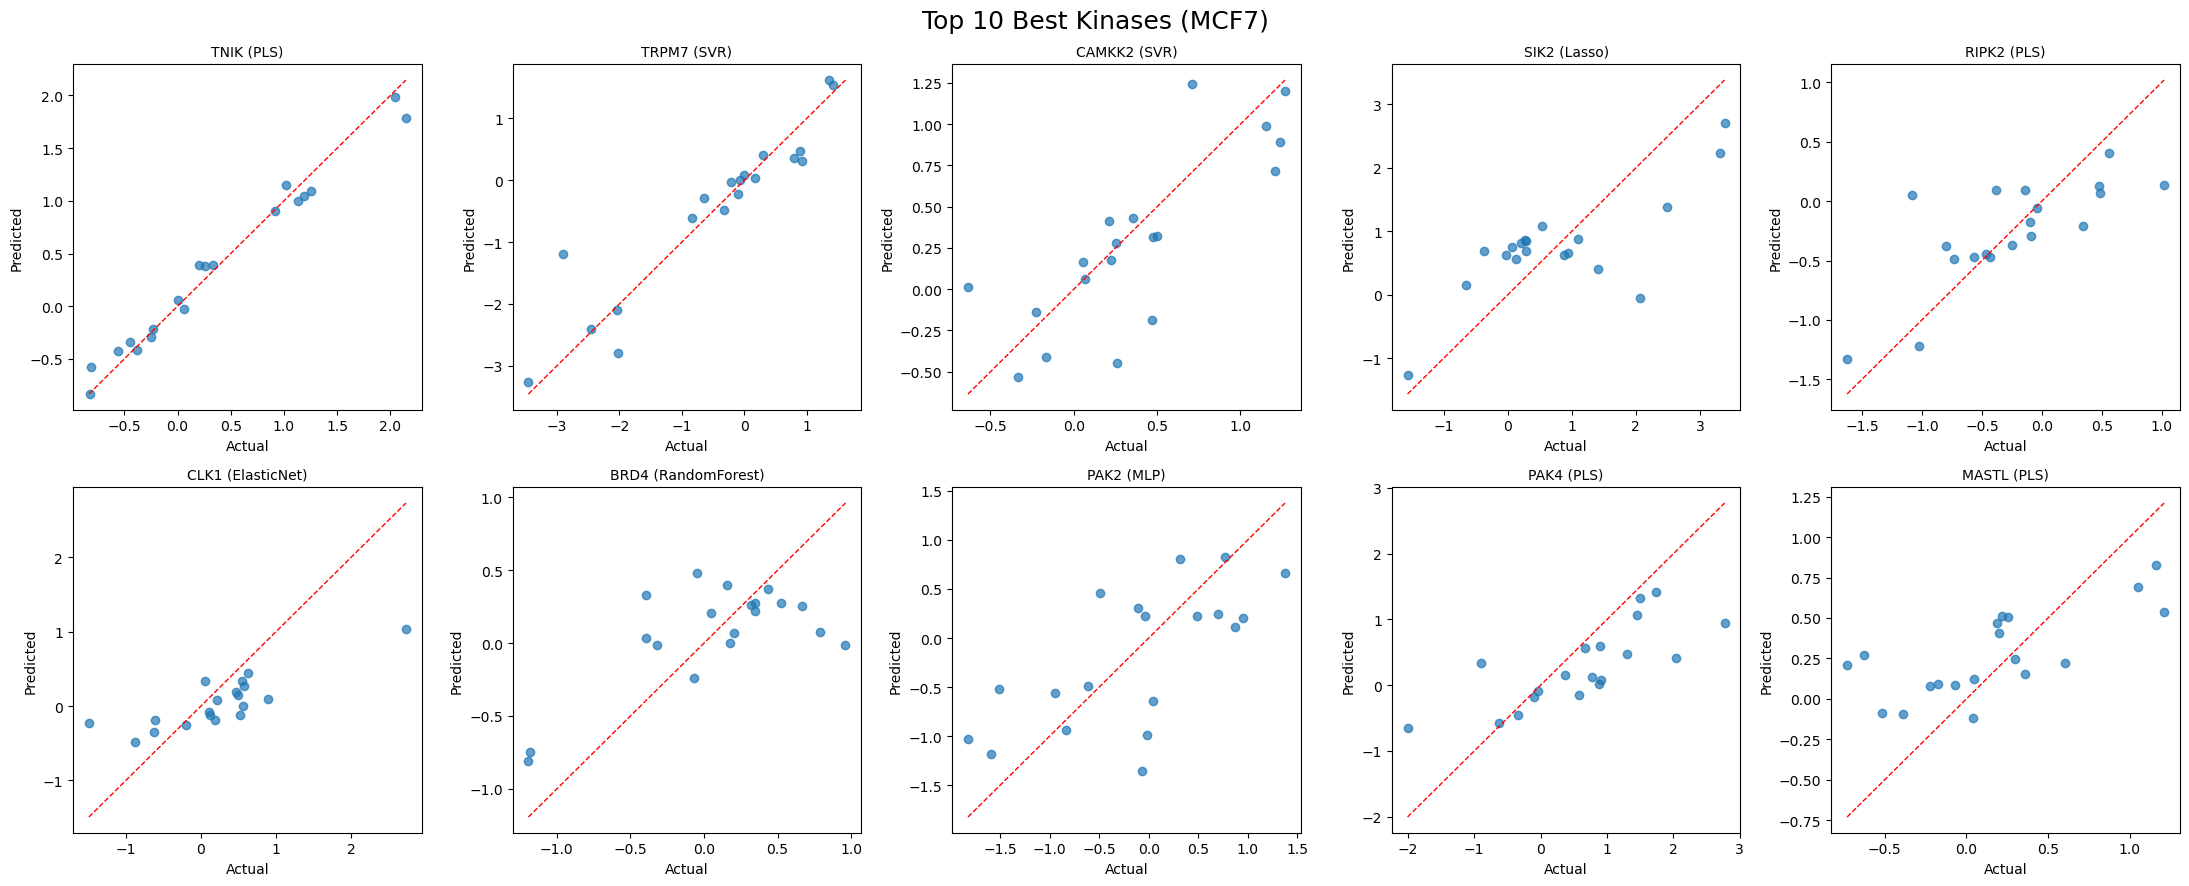

<Figure size 640x480 with 0 Axes>

In [23]:
#Generate toop 10 best

top10_best_ids = top_10_best["Kinase"].tolist()

plot_actual_vs_predicted(
    best_predictions,
    top10_best_ids,
    "Top 10 Best Kinases (MCF7)" 
)

plt.savefig(
    "Top10_Worst_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

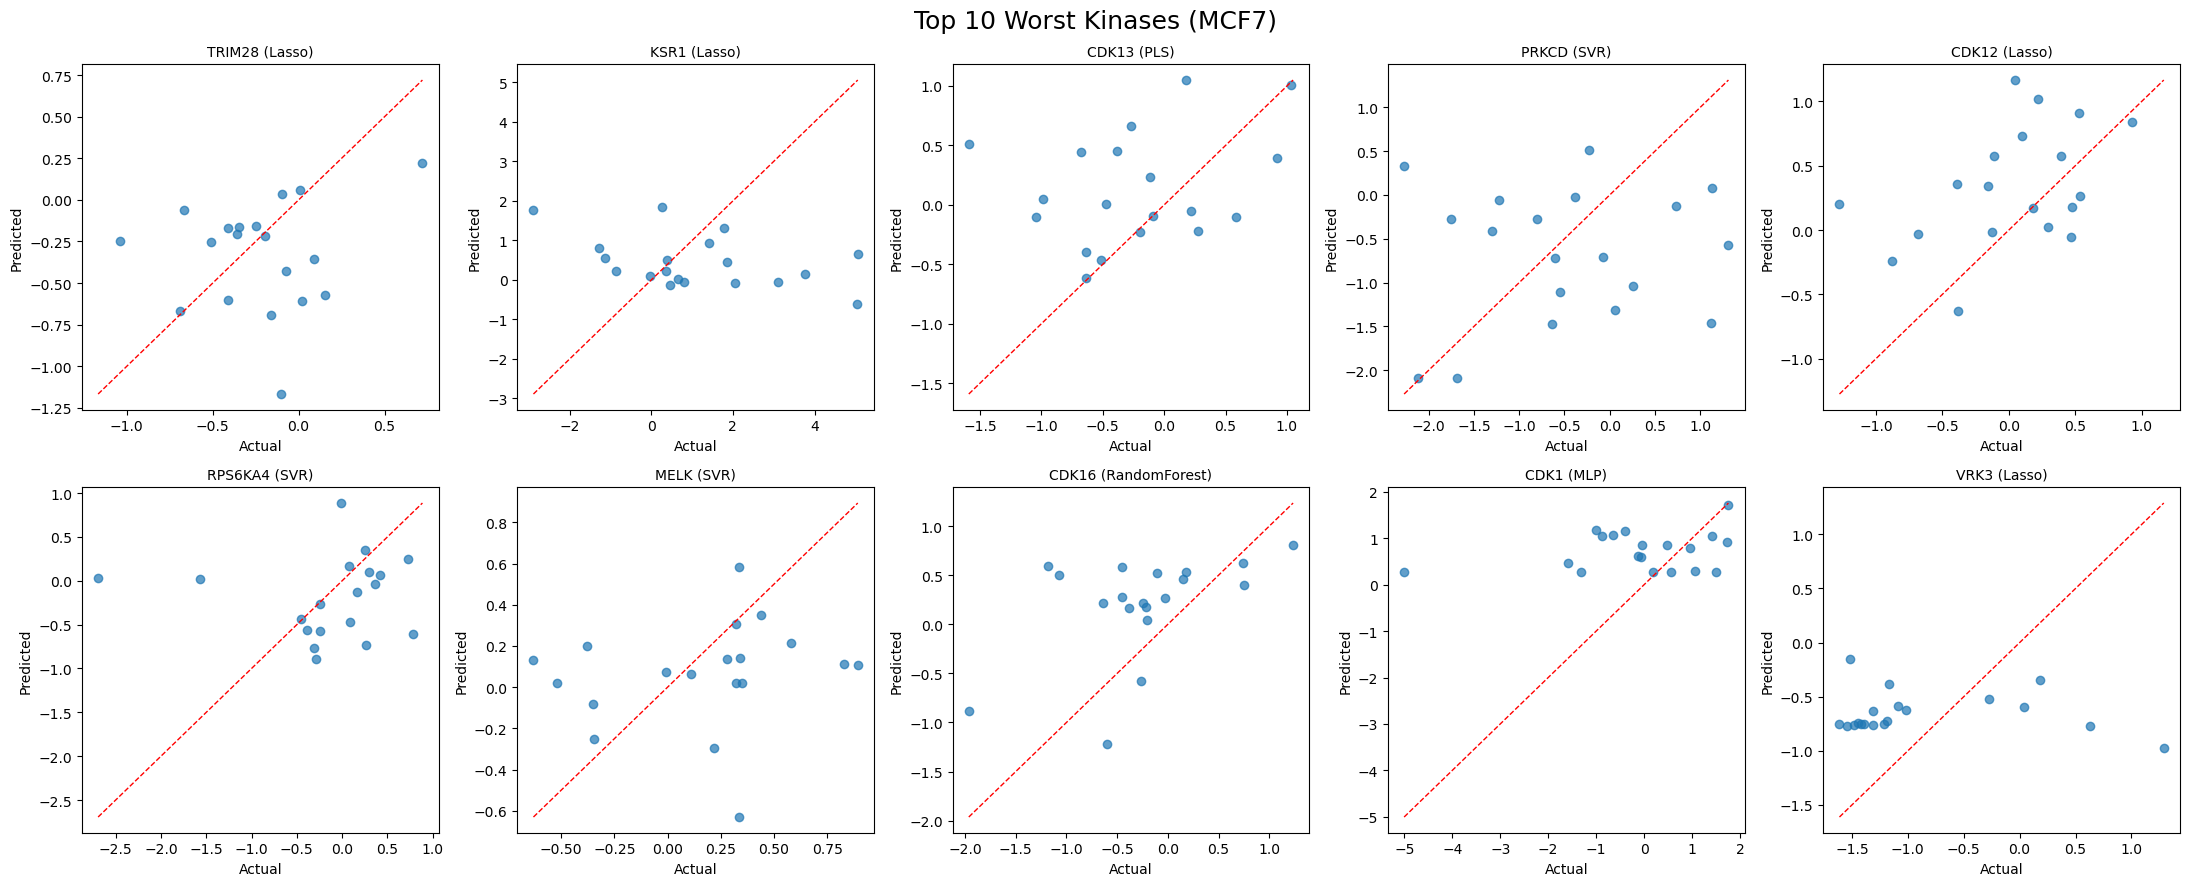

<Figure size 640x480 with 0 Axes>

In [24]:
top10_worst_ids = top_10_worst["Kinase"].tolist()

plot_actual_vs_predicted(
    best_predictions,
    top10_worst_ids,
    "Top 10 Worst Kinases (MCF7)"
)

plt.savefig(
    "Top10_Worst_Actual_vs_Predicted.png",
    dpi=300,
    bbox_inches="tight"
)

In [25]:
#Load the phosphosite counts

phosphosite_counts = pd.read_csv("phosphosite_counts.csv")

phosphosite_counts.head()

,UniprotID,GeneName,TotalPhosphosites,Phosphosites
0,P06239,LCK,6,"['LCK(Y394)', 'LCK(Y505)', 'LCK(Y192)', 'LCK(S..."
1,P12931,SRC,17,"['SRC(Y216)', 'SRC(Y338)', 'SRC(Y419)', 'SRC(Y..."
2,P06241,FYN,13,"['FYN(Y39)', 'FYN(Y420)', 'FYN(Y28)', 'FYN(Y30..."
3,P00519,ABL1,37,"['ABL1(S446)', 'ABL1(S465)', 'ABL1(Y393)', 'AB..."
4,P24941,CDK2,9,"['CDK2(T160)', 'CDK2(Y168)', 'CDK2(S46)', 'CDK..."


In [26]:
# Merge phosphosite counts with best model table

best_models = best_models.merge(
    phosphosite_counts[["UniprotID", "GeneName", "TotalPhosphosites"]],
    left_on="Kinase",
    right_on="UniprotID",
    how="left"
)

# Remove UniProt columns
best_models.drop(columns=["Kinase", "UniprotID"], inplace=True)

# Put GeneName as the first column
cols = ["GeneName"] + [c for c in best_models.columns if c != "GeneName"]
best_models = best_models[cols]

best_models.head()

,GeneName,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,TotalPhosphosites
0,EEF2K,Lasso,0.005693,0.265054,-0.126371,0.816455,19
1,CIT,RandomForest,-0.611219,0.755537,0.023617,0.480279,6
2,DCLK1,Lasso,0.200674,0.369384,0.122552,0.938032,10
3,MAP3K7,GradientBoosting,-1.415528,2.148830,0.230035,0.643804,11
4,RIPK2,PLS,0.667993,0.148958,0.556355,0.179804,10


In [27]:
best_models.columns

Index(['GeneName', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE',
       'TotalPhosphosites'],
      dtype='object')

In [28]:
# Keep only the columns needed
#When merged datarames earlier, pandas automatically created two identical phosphosite columns (_x and _y).
#for plotting R2 vs phosphosite count , i only need one phosphosite column.
best_models = best_models[
    [
        "GeneName",
        "Model",
        "Test R²",
        "TotalPhosphosites"
    ]
]

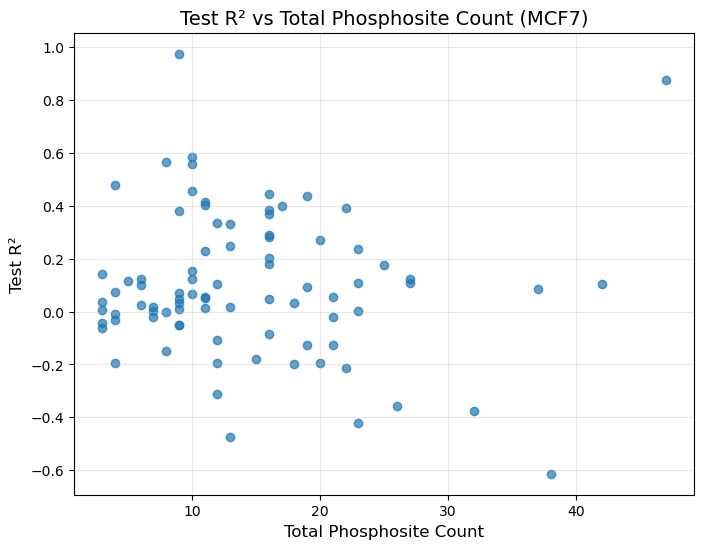

In [29]:
plt.figure(figsize=(8,6))

plt.scatter(
    best_models["TotalPhosphosites"],
    best_models["Test R²"],
    alpha=0.7
)

plt.xlabel("Total Phosphosite Count", fontsize=12)
plt.ylabel("Test R²", fontsize=12)
plt.title("Test R² vs Total Phosphosite Count (MCF7)", fontsize=14)

plt.grid(alpha=0.3)

plt.show()

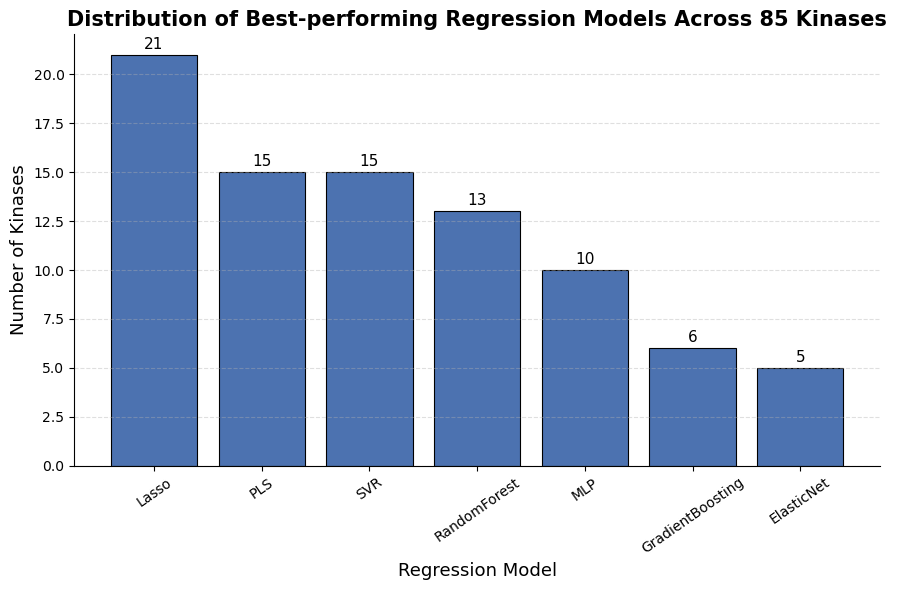

In [30]:


best_models = pd.read_csv("best_results_with_genes.csv")

model_counts = (
    best_models["Model"]
    .value_counts()
)

plt.figure(figsize=(9,6))

bars = plt.bar(
    model_counts.index,
    model_counts.values,
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.8
)

# Add count labels
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        f"{int(height)}",
        ha="center",
        fontsize=11
    )

plt.xlabel("Regression Model", fontsize=13)
plt.ylabel("Number of Kinases", fontsize=13)

plt.title(
    "Distribution of Best-performing Regression Models Across 85 Kinases",
    fontsize=15,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(rotation=35)

plt.tight_layout()

plt.savefig(
    "Figure_Model_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

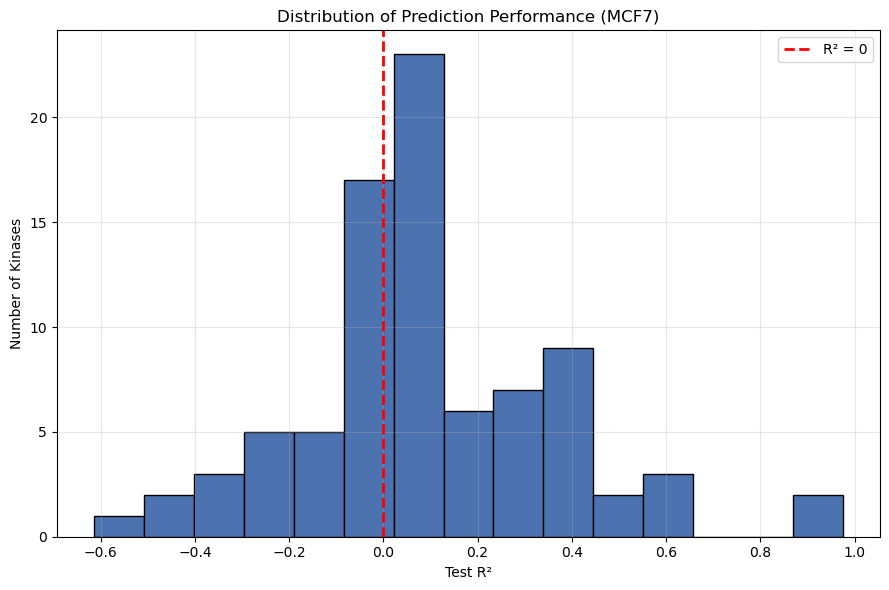

In [31]:
plt.figure(figsize=(9,6))

plt.hist(
    best_models["Test R²"],
    bins=15,
    color="#4C72B0",
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="R² = 0"
)

plt.xlabel("Test R²")
plt.ylabel("Number of Kinases")
plt.title("Distribution of Prediction Performance (MCF7)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Histogram_Test_R2_MCF7.png", dpi=300)
plt.show()

In [32]:
import pandas as pd
best_df = pd.read_csv("best_results_with_genes.csv")
target_df = pd.read_csv("target_phosphosite_counts.csv")

In [33]:
print(best_df.columns)
print(target_df.columns)

Index(['Kinase', 'Model', 'CV Mean R²', 'CV Std R²', 'Test R²', 'Test MSE'], dtype='object')
Index(['UniprotID', 'GeneName', 'TargetPhosphositeCount',
       'TargetPhosphosites'],
      dtype='object')


In [34]:
merged_df = pd.merge(
    best_df,
    target_df,
    left_on="Kinase",
    right_on="UniprotID",
    how="inner"
)

print(merged_df.shape)
merged_df.head()

(85, 10)


,Kinase,Model,CV Mean R²,CV Std R²,Test R²,Test MSE,UniprotID,GeneName,TargetPhosphositeCount,TargetPhosphosites
0,O00418,Lasso,0.005693,0.265054,-0.126371,0.816455,O00418,EEF2K,7,"['EEF2(T59)', 'EEF2(T57)', 'EEF2(T54)', 'EEF2(..."
1,O14578,RandomForest,-0.611219,0.755537,0.023617,0.480279,O14578,CIT,3,"['MYL9(S20)', 'MYL9(T19)', 'SRF(T159)']"
2,O15075,Lasso,0.200674,0.369384,0.122552,0.938032,O15075,DCLK1,6,"['CAMKK1(S74)', 'CAMKK1(S458)', 'CAMKK1(S475)'..."
3,O43318,GradientBoosting,-1.415528,2.148830,0.230035,0.643804,O43318,MAP3K7,85,"['KSR1(S406)', 'RAB8A(T72)', 'PTPN3(S359)', 'H..."
4,O43353,PLS,0.667993,0.148958,0.556355,0.179804,O43353,RIPK2,14,"['IRF5(S446)', 'IRF5(S435)', 'CRK(S41)', 'CRK(..."


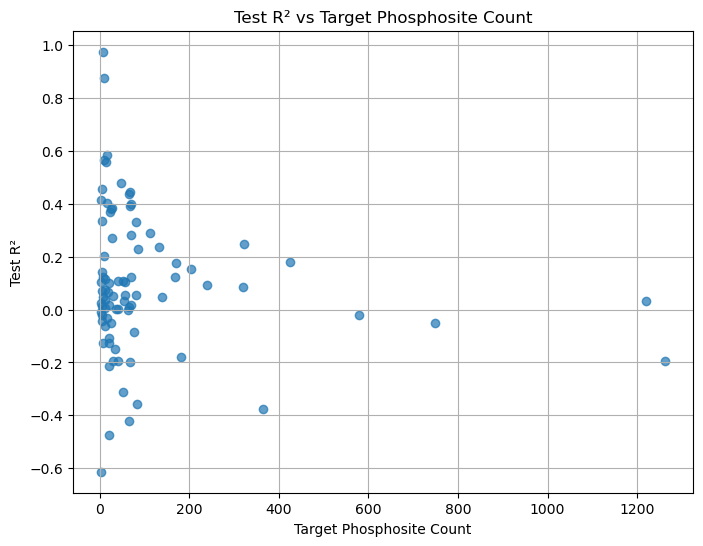

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["TargetPhosphositeCount"],
    merged_df["Test R²"],
    alpha=0.7
)

plt.xlabel("Target Phosphosite Count")
plt.ylabel("Test R²")
plt.title("Test R² vs Target Phosphosite Count")

plt.grid(True)

plt.savefig(
    "R2_vs_Target_Phosphosite_Count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

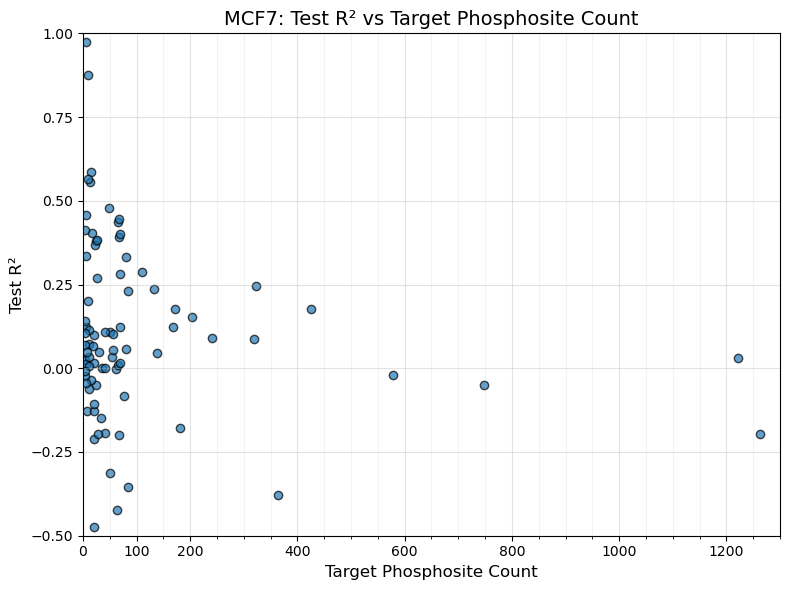

In [36]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# Create figure
plt.figure(figsize=(8,6))

# Scatter plot
plt.scatter(
    merged_df["TargetPhosphositeCount"],
    merged_df["Test R²"],
    alpha=0.7,
    edgecolor="black"
)

# Labels and title
plt.xlabel("Target Phosphosite Count", fontsize=12)
plt.ylabel("Test R²", fontsize=12)
plt.title("MCF7: Test R² vs Target Phosphosite Count", fontsize=14)

# -------------------------------------------------
# SAME AXES FOR ALL CELL LINES
# -------------------------------------------------
plt.xlim(0, 1300)
plt.ylim(-0.5, 1.0)

# Major x-axis ticks
plt.xticks(
    [0, 100, 200, 400, 600, 800, 1000, 1200],
    fontsize=10
)

# Major y-axis ticks
plt.yticks(
    [-0.5, -0.25, 0, 0.25, 0.5, 0.75, 1.0],
    fontsize=10
)

# Minor ticks every 50 phosphosites
ax = plt.gca()
ax.xaxis.set_minor_locator(MultipleLocator(50))

# Gridlines
plt.grid(which="major", alpha=0.35)
plt.grid(which="minor", alpha=0.15)

# -------------------------------------------------

plt.tight_layout()

# Save figure
plt.savefig(
    "MCF7_R2_vs_TargetPhosphositeCount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
# Merge phosphosite counts with ML results
r2_phosphosite = best_results_with_genes.merge(
    phosphosite_counts[['GeneName', 'TotalPhosphosites']],
    on='GeneName',
    how='left'
)

print(r2_phosphosite.head())

   Kinase GeneName             Model  CV Mean R²  CV Std R²   Test R²  \
0  O00418    EEF2K             Lasso    0.005693   0.265054 -0.126371   
1  O14578      CIT      RandomForest   -0.611219   0.755537  0.023617   
2  O15075    DCLK1             Lasso    0.200674   0.369384  0.122552   
3  O43318   MAP3K7  GradientBoosting   -1.415528   2.148830  0.230035   
4  O43353    RIPK2               PLS    0.667993   0.148958  0.556355   

   Test MSE  TotalPhosphosites  
0  0.816455                 19  
1  0.480279                  6  
2  0.938032                 10  
3  0.643804                 11  
4  0.179804                 10  


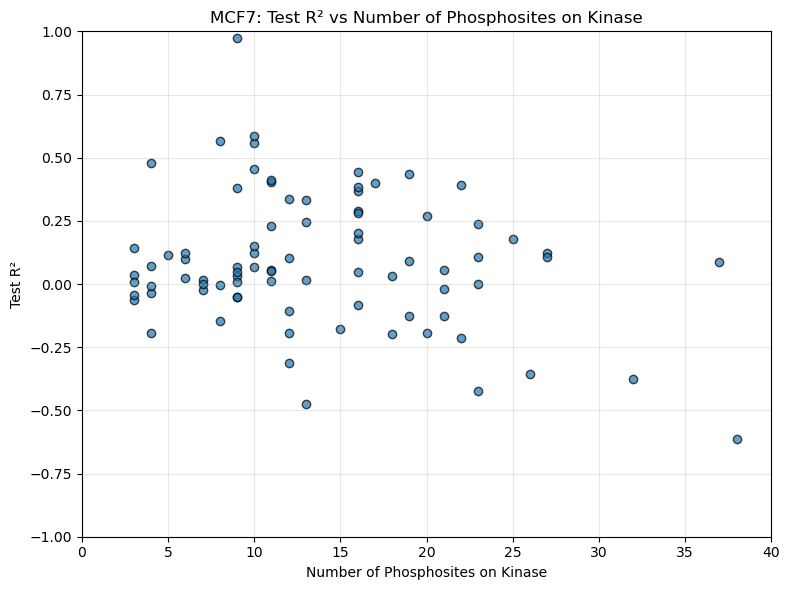

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    r2_phosphosite["TotalPhosphosites"],
    r2_phosphosite["Test R²"],
    alpha=0.7,
    edgecolor="black"
)

plt.xlabel("Number of Phosphosites on Kinase")
plt.ylabel("Test R²")
plt.title("MCF7: Test R² vs Number of Phosphosites on Kinase")

# ---------- Fixed axes ----------
plt.xlim(0, 40)
plt.ylim(-1.0, 1.0)
# -------------------------------

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("MCF7_R2_vs_Kinase_Phosphosite_Count.png", dpi=300)

plt.show()

In [39]:
print("Kinases:", len(merged_sites))

print("Total kinase phosphosites:",
      merged_sites["TotalPhosphosites"].sum())

print("Total target phosphosites:",
      merged_sites["TargetPhosphositeCount"].sum())

NameError: name 'merged_sites' is not defined